<a href="https://colab.research.google.com/github/miriamamin1213-ux/Seed42_Models/blob/main/XGB_Hecktor_NoSmote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 58.4MB/s]


(423, 12)

Train samples:
HPV Status
1.0    320
0.0     18
Name: count, dtype: int64

Test samples:
HPV Status
1.0    80
0.0     5
Name: count, dtype: int64

Training class distribution - No SMOTE:
HPV Status
1.0    320
0.0     18
Name: count, dtype: int64

Classification Report

              precision    recall  f1-score   support

         0.0     0.3333    0.2000    0.2500         5
         1.0     0.9512    0.9750    0.9630        80

    accuracy                         0.9294        85
   macro avg     0.6423    0.5875    0.6065        85
weighted avg     0.9149    0.9294    0.9210        85

Confusion Matrix
[[ 1  4]
 [ 2 78]]

Accuracy:            0.9294
Balanced Accuracy:   0.5875
F1-score:            0.9630
AUC:                 0.8588

XGBoost SUMMARY
Model : XGBoost
Input Features : 11
Learning Rate : 0.1
Optimiser : N/A
Class Weights : None
SMOTE : No
Training Patients : 338
Test Patients : 85
Seed : 42

Final Results
---------------------------
Accuracy            : 0.92

/tmp/ipykernel_2336/328935222.py:94: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"] = df["T-stage"].replace({
/tmp/ipykernel_2336/328935222.py:102: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"] = df["N-stage"].replace({
/tmp/ipykernel_2336/328935222.py:109: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_sil

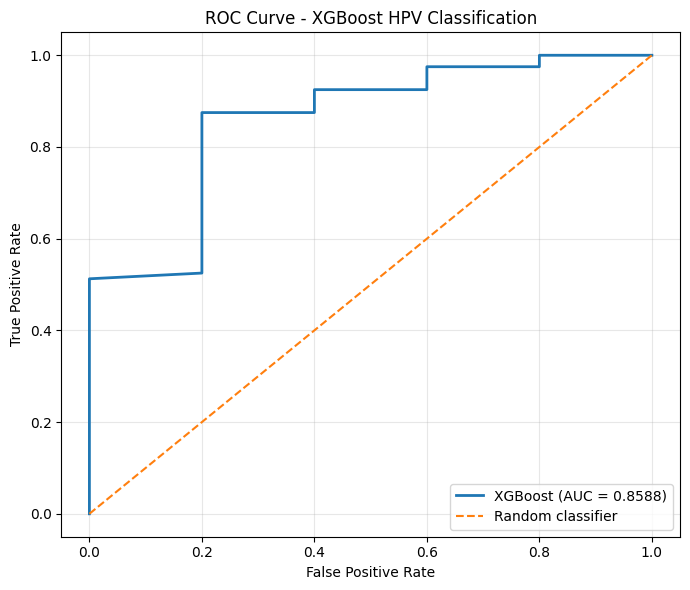

AUC: 0.8588


In [1]:
# ============================================================
# XGBoost42_Hecktor - NO SMOTE
# ============================================================

!pip install -q gdown

import gdown

gdown.download(
    id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
    output="HPV2025.xlsx",
    quiet=False
)

import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)


SEED = 42

seed_everything(SEED)


# ------------------------------------------------------------
# Read Dataset
# ------------------------------------------------------------

df = pd.read_excel("HPV2025.xlsx")

df = df.dropna(subset=["HPV Status"])


tobacco_mode = df["Tobacco Consumption"].mode()[0]

df["Tobacco Consumption"] = df[
    "Tobacco Consumption"
].fillna(tobacco_mode)


alcohol_mode = df["Alcohol Consumption"].mode()[0]

df["Alcohol Consumption"] = df[
    "Alcohol Consumption"
].fillna(alcohol_mode)


df = df.drop(
    columns=[
        "PatientID",
        "CenterID",
        "Task 1",
        "Task 2",
        "Task 3"
    ]
)

df = df.dropna()

print(df.shape)


# ------------------------------------------------------------
# Encode stages
# ------------------------------------------------------------

df["T-stage"] = df["T-stage"].replace({
    "T0": 0,
    "T1": 1,
    "T2": 2,
    "T3": 3,
    "T4": 4
})

df["N-stage"] = df["N-stage"].replace({
    "N0": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3
})

df["M-stage"] = df["M-stage"].replace({
    "M0": 0,
    "M1": 1
})


# ------------------------------------------------------------
# Features
# ------------------------------------------------------------

X = df[
    [
        "Age",
        "Gender",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "Relapse",
        "RFS",
        "Treatment",
        "T-stage",
        "N-stage",
        "M-stage"
    ]
]

y = df["HPV Status"]


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=SEED

)


print("\nTrain samples:")

print(y_train.value_counts())


print("\nTest samples:")

print(y_test.value_counts())


# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ------------------------------------------------------------
# NO SMOTE
# ------------------------------------------------------------

print("\nTraining class distribution - No SMOTE:")

print(y_train.value_counts())


# ------------------------------------------------------------
# XGBoost Model
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=SEED,
    eval_metric="logloss"
)


model.fit(

    X_train,

    y_train

)


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predicted = model.predict(

    X_test

)


probabilities = model.predict_proba(

    X_test

)[:, 1]


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print()

print("Classification Report\n")

print(

    classification_report(

        y_test,

        predicted,

        digits=4

    )

)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(

    y_test,

    predicted

)

print("Confusion Matrix")

print(cm)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = (

    (predicted == y_test).sum()

    /

    len(y_test)

)


bal_acc = balanced_accuracy_score(

    y_test,

    predicted

)


f1 = f1_score(

    y_test,

    predicted

)


auc = roc_auc_score(

    y_test,

    probabilities

)


print()

print(
    f"Accuracy:            {accuracy:.4f}"
)

print(
    f"Balanced Accuracy:   {bal_acc:.4f}"
)

print(
    f"F1-score:            {f1:.4f}"
)

print(
    f"AUC:                 {auc:.4f}"
)


# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print()

print("====================================")

print("XGBoost SUMMARY")

print("====================================")

print(
    "Model : XGBoost"
)

print(
    "Input Features : 11"
)

print(
    "Learning Rate : 0.1"
)

print(
    "Optimiser : N/A"
)

print(
    "Class Weights : None"
)

print(
    "SMOTE : No"
)

print(
    "Training Patients :",
    len(y_train)
)

print(
    "Test Patients :",
    len(y_test)
)

print(
    "Seed :",
    SEED
)

print()

print("Final Results")

print("---------------------------")

print(
    f"Accuracy            : {accuracy:.4f}"
)

print(
    f"Balanced Accuracy   : {bal_acc:.4f}"
)

print(
    f"F1-score            : {f1:.4f}"
)

print(
    f"AUC                 : {auc:.4f}"
)

print()

print("Confusion Matrix")

print(cm)

print()

print("Analysis Complete.")


# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt


y_score = probabilities


fpr, tpr, thresholds = roc_curve(

    y_test,

    y_score

)


auc = roc_auc_score(

    y_test,

    y_score

)


plt.figure(figsize=(7, 6))


plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f'XGBoost (AUC = {auc:.4f})'

)


# Random classifier

plt.plot(

    [0, 1],

    [0, 1],

    linestyle='--',

    linewidth=1.5,

    label='Random classifier'

)


plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve - XGBoost HPV Classification'
)

plt.legend(
    loc='lower right'
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


print(
    f"AUC: {auc:.4f}"
)